In [1]:
# Data processing
import pandas as pd
import xarray as xr
import numpy as np
import math

# Plotting 
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import regionmask

# Stat and ML
from scipy import stats
from sklearn.model_selection import train_test_split
from tqdm import tqdm 
from statsmodels.tsa.stattools import grangercausalitytests
from scipy.stats import chi2
from sklearn.ensemble import RandomForestRegressor
from scipy.signal import detrend
from sklearn.decomposition import PCA
from sklearn.linear_model import RidgeCV
from sklearn.model_selection import cross_val_score, KFold

# Personal library
from models.granger_pca import GrangerPCA
from models.teleconnection_models import RegressionAnalysis, CompositeAnalysis, CanonicalCorrelationAnalysis, SpatialAveraging
from utils.granger_causality_test import test_granger_causality, test_granger_causality_non_parametric
from utils.xarray_numpy import xr2np, np2D_to_np3D
from utils.utils import generate_past_data, lag_analysis, plot_lag_results, compute_aic_bic, gaussianise_precip
from utils.plot_weights import *

np.random.seed(1234)

## Loading data

In [2]:
region = 'Australia'

if region == 'Australia':
    ndvi = np.genfromtxt('/home/homer/Documents/Research/Projects/ENSO_NDVI_CD/gpca_ENSO_Africa/dataout/AUSTRALIA/NDVI/X.tsv')
    oscillation = np.genfromtxt('/home/homer/Documents/Research/Projects/ENSO_NDVI_CD/gpca_ENSO_Africa/dataout/AUSTRALIA/NDVI/Y.tsv')
    mask = xr.open_dataset('/home/homer/Documents/Research/Projects/ENSO_NDVI_CD/gpca_ENSO_Africa/dataout/AUSTRALIA/NDVI/na_mask.nc')
    extent = [110, 155, -10, -40]
    
if region == 'South America':
    ndvi = np.genfromtxt('/home/homer/Documents/Research/Projects/ENSO_NDVI_CD/gpca_ENSO_Africa/dataout/SOUTH_AMERICA/NDVI/X.tsv')
    oscillation = np.genfromtxt('/home/homer/Documents/Research/Projects/ENSO_NDVI_CD/gpca_ENSO_Africa/dataout/SOUTH_AMERICA/NDVI/Y.tsv')
    mask = xr.open_dataset('/home/homer/Documents/Research/Projects/ENSO_NDVI_CD/gpca_ENSO_Africa/dataout/SOUTH_AMERICA/NDVI/na_mask.nc')
    extent = [-90, -30, 20,-60]

# removing masked values
na_mask = mask['na_mask'].values 

# Preprocessing: Removing anomalies
seasonalities = ndvi.reshape(20, 23, -1).mean(axis=0)
ndvi_anomalies = ndvi.reshape(20, 23, -1) - seasonalities

# Preprocessing: Creating a 2D numpy array
anomalies = ndvi_anomalies.reshape(460, -1)
shape = na_mask.shape

## Data preprocessing

In [3]:
# Detrending
anomalies = detrend(anomalies, axis=0, type='linear')

In [4]:
# Data splitting
train_ratio = 0.8
    
n = len(anomalies)
train_size = int(n * train_ratio)

anomalies_train = anomalies[:train_size, :]
anomalies_test  = anomalies[train_size:, :]

oscillation_train = oscillation[:train_size]
oscillation_test  = oscillation[train_size:]

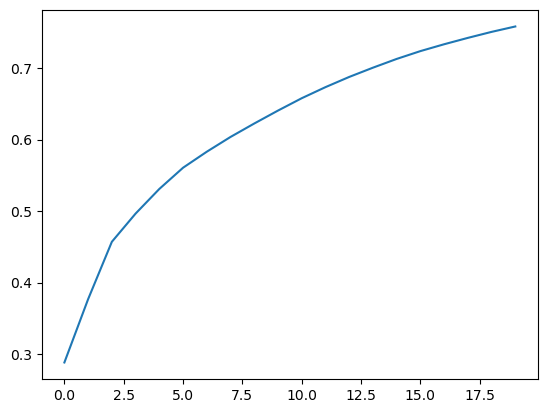

In [5]:
# Principal Component Analysis
ncp = 20
    
pca = PCA(n_components=ncp)
pca.fit(anomalies_train)
plt.plot(np.cumsum(pca.explained_variance_ratio_))


anomalies_pca_train = pca.transform(anomalies_train)
anomalies_pca_test = pca.transform(anomalies_test)

anomalies_pca = pca.transform(anomalies)

## Fitting Granger PCA
* Seting maxlag to *None* to that optimal lag is selected to maximise the *lag_criterion* score of a model predicting $Y$ from $X$ and $Y$'s pasts.
* Different algorithms are available: *diff_ratio* maximise the F-statistic, *ratio* maximise the likelihood ratio and *difference* maximise the RSS difference

100%|██████████| 10/10 [00:02<00:00,  3.50it/s]


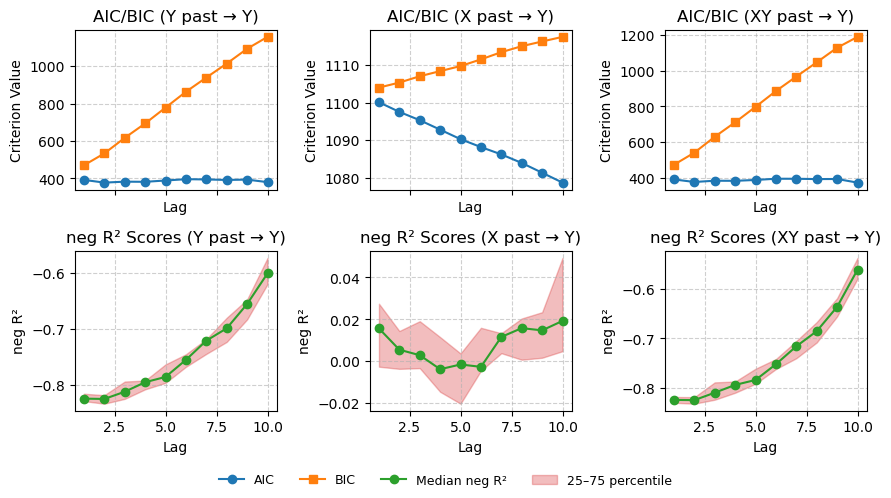

       eigs
0  0.161142


In [6]:
lag = 3
alphas=np.logspace(-2, 5, 100)
gpca = GrangerPCA(maxlag=None, maxlags=range(1, 11), method='diff_ratio', lag_criterion='BIC' )
gpca.fit(oscillation_train[:, None], anomalies_pca_train, plot_lag_analysis=True, verbose=True)

In [7]:
cp_test_gpca = gpca.transform(anomalies_pca_test)

## Fitting other algorithms
* Using the same optimal time lag found during Granger PCA analysis 

In [8]:
ca = CompositeAnalysis(maxlag=gpca.maxlag)
ca.fit(oscillation_train[:, None], anomalies_pca_train)
cp_test_ca = ca.transform(anomalies_pca_test, type='PosNeg')

ra = RegressionAnalysis(maxlag=gpca.maxlag)
ra.fit(oscillation_train[:, None], anomalies_pca_train)
cp_test_ra = ra.transform(anomalies_pca_test)

cca = CanonicalCorrelationAnalysis(maxlag=gpca.maxlag, n_components=1)
cca.fit(oscillation_train[:, None], anomalies_pca_train)
cp_test_cca = cca.transform(anomalies_pca_test)

sa = SpatialAveraging()
sa.fit(oscillation_train[:, None], anomalies_train)
cp_test_sa = sa.transform(anomalies_test)


## Testing Granger causality 
* We test Granger causality between the extracted component $\tilde{Y}$ and the climate oscillation $X$

In [9]:
results_gpca = test_granger_causality(oscillation_test[:, None], cp_test_gpca[:, 0], maxlag=[gpca.maxlag])
results_ra = test_granger_causality(oscillation_test[:, None], cp_test_ra, maxlag=[gpca.maxlag])
results_ca = test_granger_causality(oscillation_test[:, None], cp_test_ca, maxlag=[gpca.maxlag])
results_cca = test_granger_causality(oscillation_test[:, None], cp_test_cca, maxlag=[gpca.maxlag])
results_sa = test_granger_causality(oscillation_test[:, None], cp_test_sa, maxlag=[gpca.maxlag])

### Results

In [10]:
# Combine results 
combined = pd.concat(
    [
        results_gpca[results_gpca['lag'] == gpca.maxlag],
        results_cca[results_cca['lag'] == gpca.maxlag],
        results_ca[results_ca['lag'] == gpca.maxlag],
        results_ra[results_ra['lag'] == gpca.maxlag],
        results_sa[results_sa['lag'] == gpca.maxlag]
    ],
    keys=['GPCA', 'CCA', 'Composites', 'Regression', 'Spatial Average']
).reset_index(level=0).rename(columns={'level_0': 'Method'})

# Export to LaTeX
latex_table = combined[['F_statistic', 'p_value']].to_latex(
    index=True,         
    caption=f"Comparison of Results by Method at lag = {gpca.maxlag}",
    label="tab:results_by_method",
    float_format="%.6f",  
    escape=True         
)

# Save to file
with open(f"tables/teleconnection_pvalues_NDVI_{region}_lag-{gpca.maxlag}.tex", "w") as f:
    f.write(latex_table)


In [11]:
combined

,Method,lag,Y_column,F_statistic,df1,df2,p_value,F_critical,alpha_used,interpretation
0,GPCA,1,1,2.406994,1,89,0.124343,3.948084,0.05,Fail to reject H₀: no Granger causality for Y ...
0,CCA,1,1,0.000413,1,89,0.983839,3.948084,0.05,Fail to reject H₀: no Granger causality for Y ...
0,Composites,1,1,0.058701,1,89,0.809119,3.948084,0.05,Fail to reject H₀: no Granger causality for Y ...
0,Regression,1,1,0.002564,1,89,0.959727,3.948084,0.05,Fail to reject H₀: no Granger causality for Y ...
0,Spatial Average,1,1,0.443386,1,89,0.507215,3.948084,0.05,Fail to reject H₀: no Granger causality for Y ...


In [12]:
idx = 0 # Which GPC

weights_gpca = normalise((gpca.vects_[:, idx] @ pca.components_))
weights_ra = normalise((ra.lr.coef_.T @ pca.components_)[0, :])
weights_ca = normalise(ca.composites['PosNeg'].to_numpy() @ pca.components_)
weights_cca = normalise((cca.cca.y_rotations_.T @ pca.components_)[0, :])
weights_sa = sa.weights_
    
weights = {'GPCA':{'weights':weights_gpca, 'p-value':results_gpca[results_gpca['lag']==gpca.maxlag]['p_value']}, 
            'Regression':{'weights':weights_ra, 'p-value':results_ra[results_ra['lag']==gpca.maxlag]['p_value']},
            'Composites':{'weights':weights_ca, 'p-value':results_ca[results_ca['lag']==gpca.maxlag]['p_value']},
            'CCA':{'weights':weights_cca, 'p-value':results_cca[results_cca['lag']==gpca.maxlag]['p_value']}
            # 'Average':{'weights':weights_sa, 'p-value':results_sa[results_sa['lag']==gpca.maxlag]['p_value_parametric']}
        }

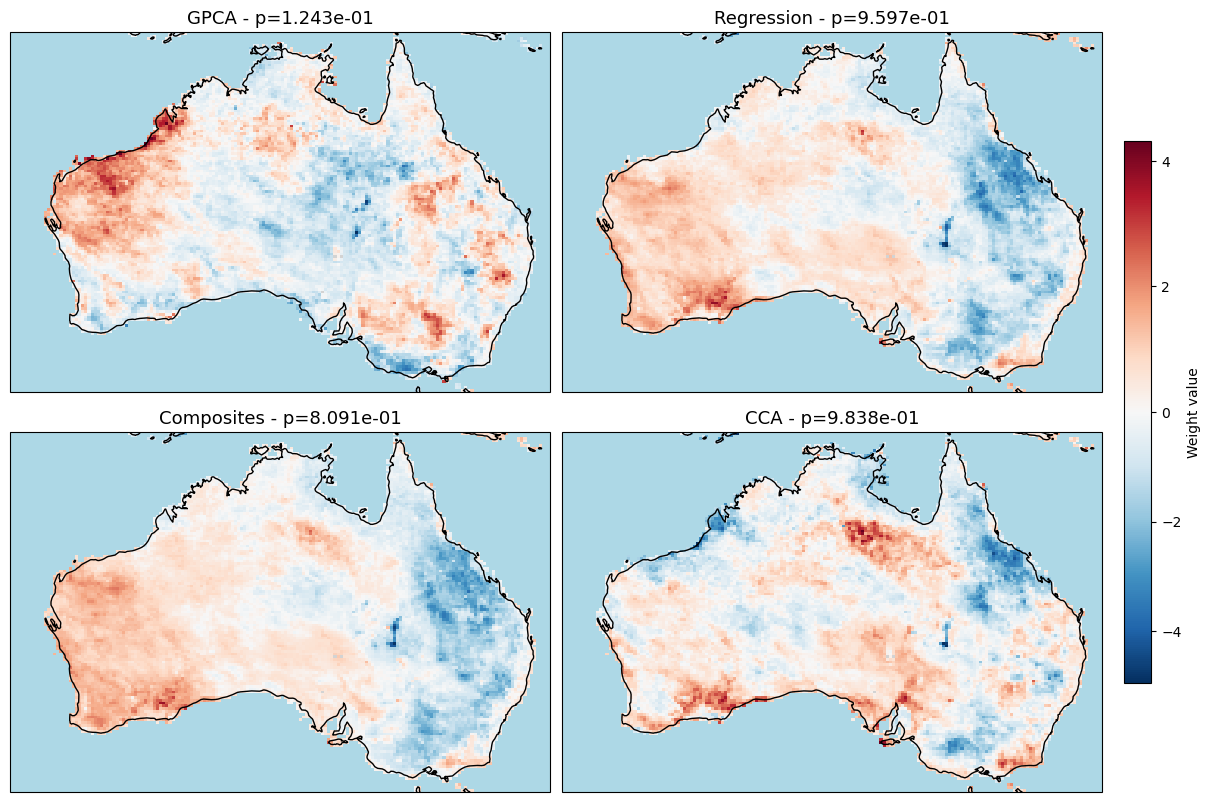

In [13]:
path = f'figures/teleconnection_weights_NDVI_{region}_lag-{gpca.maxlag}.pdf'

easting = mask.easting.values
northing = mask.northing.values
plot_weight_maps(weights, 'NDVI', lon=None, lat=None, extent=extent, easting=easting, northing=northing, save_path=path, na_mask=na_mask)